# Inverted Repeats — SNP frequency (model-detected subset)

Fork of `ir_snp_frequency_notebook.ipynb`. Only §2.1 differs: the DR set is
`Inverted_Repeat_detected.bed` (model-detected, ~1.5k loci) instead of
all DR in `Inverted_Repeat_test.csv`. Spacer is still recovered from the test CSV
by joining on (chr, motif_start, motif_end, strand).


The goal of this notebook is to compute the level of variation (diversity, divergence) in non-B DNA motifs and their flanks.

# Library

Load this before running the rest of the notebook

In [2]:

try:
    get_ipython().run_line_magic('load_ext', 'rpy2.ipython')
    print('rpy2 loaded')
except Exception as e:
    print('rpy2 not available (R cells will fail, which is expected for the pipeline-only run):', e)


rpy2 not available (R cells will fail, which is expected for the pipeline-only run): No module named 'rpy2'


In [3]:


import re

def trinucl_subrate(snps, motifsequences):
    
    # One count and one array per possible trinucleotide.
    nucleotides = ['A','T','G','C','N']
    trinucleotides = []
    for x in nucleotides:
        for y in nucleotides:
            for z in nucleotides:
                trinucleotides.append(x+y+z)
    trinucleotidesdict = {}
    for trinucleotide in trinucleotides:
        trinucleotidesdict[trinucleotide] = [0,[]]

    # Count trinucleotide occurrences and match them against SNPs.
    for motifsequence in motifsequences:
        motifsequence = motifsequence.strip()
        if motifsequence[0] == '>':
            chrom, start, end = re.split('[:,\-]',motifsequence[1:])
            start = int(start)
            end = int(end)
        else:
            motifsequence = motifsequence.replace('a', 'A')
            motifsequence = motifsequence.replace('t', 'T')
            motifsequence = motifsequence.replace('c', 'C')
            motifsequence = motifsequence.replace('g', 'G')
            motifsequence = motifsequence.replace('n', 'N')
            for i in range(1, len(motifsequence)-1):
                trinucl = motifsequence[i-1]+motifsequence[i]+motifsequence[i+1]
                pos = start + i
                key = chrom+'|'+str(pos)+'|'+str(pos+1)
                trinucleotidesdict[trinucl][0] += 1
                if key in snpdict:
                    trinucleotidesdict[trinucl][1].append(snpdict[key])

    # Count each substitution type per trinucleotide and derive the rates.
    subrates = {}
    for trinucleotide in trinucleotidesdict:
        count, snps = trinucleotidesdict[trinucleotide]
        subs = [0,0,0,0,0] # A, T, G, C, N
        for snp in snps:
            ref, alt = snp
            if ref != trinucleotide[1]:
                print('ERROR: snp ref does not match center nucleotide')

# changed for multiple SNPs in same trinucl. The trinucl is counted once but SNPs are all counted. 
# This could (unlikely but mathematically possible, sum up to more than 1.0)

            if 'A' in alt:
                subs[0] +=1
            if 'T' in alt:
                subs[1] +=1
            if 'G' in alt:
                subs[2] +=1
            if 'C' in alt:
                subs[3] +=1
            if 'N' in alt:
                subs[4] += 1

        counter = 0
        nucls = ['A','T','G','C','N']
        for sub in subs:
            if count != 0:
                rate = float(int(sub) / count)
            else:
                rate = 0
            subrates[trinucleotide+'->'+nucls[counter]] = [rate,sub,count]
            counter += 1
    return(subrates)

# 4. Inverted Repeats

End-to-end runnable pipeline (hg38 / gnomAD / detected-test DR). 



## Setup

All intermediate files are written into `results/ir_notebook_run/`

In [4]:
import os, sys, re, subprocess, random
from pathlib import Path
import pandas as pd
import numpy as np

BASE    = os.environ.get("SNP_AF_BASE", "/path/to/snp_af_analysis")
WORKDIR = f"{BASE}/results/ir_notebook_detected_run"
Path(WORKDIR).mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)

os.environ["BASE"]        = BASE
os.environ["CHROM_SIZES"] = f"{BASE}/reference/hg38.chrom.sizes"
os.environ["GAPS_BED"]    = f"{BASE}/annotations/hg38_gaps.bed"
os.environ["CODING_BED"]  = f"{BASE}/annotations/coding_regions.bed" # GENCODE basic gene annotation, filtered to only include CDS regions
os.environ["REPEAT_BED"]  = f"{BASE}/annotations/repetitive_elements.bed" # RepeatMasker annotation from UCSC
os.environ["SNP_DIR"]     = f"{BASE}/snp_data/gnomad"
os.environ["PATH"]        = os.environ.get("BEDTOOLS_BIN", "") + ":" + os.environ["PATH"]
# Stage-1 (NR-Contrastive) outputs and experimental splits
# Override with environment variables; the defaults are the paths used for the paper.
PU_RESULTS      = os.environ.get("NONB_PU_RESULTS",
    "/path/to/pu_results")
EXPERIMENT_DATA = os.environ.get("NONB_EXPERIMENT_DATA",
    "/path/to/Experiment_Data")
IWTOMICS_DIR    = os.environ.get("IWTOMICS_DIR",
    "/path/to/nonb-nrcl-paper/snp_analysis/iwtomics")


random.seed(42)
np.random.seed(42)
print("cwd:", os.getcwd())
print("bedtools:", subprocess.run("which bedtools", shell=True, capture_output=True, text=True).stdout.strip())


cwd: /data/haotian/qianying/snp_af_analysis/results/ir_notebook_detected_run
bedtools: /home/haz19024/softwares/bedtools2/bin/bedtools


## 2.1 Retrieve annotation (model-detected IR)

`Inverted_Repeat_detected.bed` contains ~1.5k model-selected IR loci (9 columns,
no spacer). Spacer is recovered from the test CSV by joining on
(chr, motif_start, motif_end, strand). 

In [5]:
IR_BED   = f"{PU_RESULTS}/Inverted_Repeat/Inverted_Repeat_detected.bed"
TEST_CSV = f"{EXPERIMENT_DATA}/Inverted_Repeat_test.csv"

# Detected BED: chr, win_start, win_end, strand, motif_start, motif_end, sequence, p_value, q_value
ir_df = pd.read_csv(IR_BED, sep="\t")
print(f"detected IR rows: {len(ir_df)}")
ir_df["motif_start"] = ir_df["motif_start"].astype(int)
ir_df["motif_end"]   = ir_df["motif_end"].astype(int)
ir_df = ir_df.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)
print(f"after dedup: {len(ir_df)}")

# Pull spacer from test CSV (features field)
test_df = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","features","label"])
test_df = test_df[test_df["label"] == "Inverted_Repeat"].copy()
test_df["motif_start"] = test_df["motif_start"].astype(int)
test_df["motif_end"]   = test_df["motif_end"].astype(int)
_re_spacer = re.compile(r"spacer=(\d+)")
test_df["spacer"] = test_df["features"].apply(
    lambda s: int(_re_spacer.search(str(s)).group(1)) if _re_spacer.search(str(s)) else None)
test_df = test_df.drop_duplicates(subset=["chr","motif_start","motif_end","strand"])

ir_df = ir_df.merge(test_df[["chr","motif_start","motif_end","strand","spacer"]],
                    on=["chr","motif_start","motif_end","strand"], how="left")
n_before = len(ir_df)
ir_df = ir_df.dropna(subset=["spacer"])
ir_df["spacer"] = ir_df["spacer"].astype(int)
print(f"with spacer filled: {len(ir_df)}/{n_before}")

# 1-based inclusive → 0-based half-open
ir_df["motif_start"] = ir_df["motif_start"] - 1
# motif_end already 1-based inclusive; -1 to get the last base (0-based), +1 for half-open → no change

ir_df[["chr","motif_start","motif_end","spacer"]].to_csv(
    "InvertedRepeats.bed", sep="\t", header=False, index=False)
print(f"wrote InvertedRepeats.bed with {len(ir_df)} rows")


detected IR rows: 46530
after dedup: 46530
with spacer filled: 46530/46530
wrote InvertedRepeats.bed with 46530 rows


NCNR filter (remove overlaps with coding + repetitive) and apply the published 100-bp motif length threshold.


In [6]:
%%bash
set -euo pipefail

# Build hg38 NCNR = coding ∪ repetitive (merged) once
if [ ! -f NCNR.hg38.bed ]; then
    cat "$CODING_BED" "$REPEAT_BED" | sort -k1,1 -k2,2n | bedtools merge -i stdin > NCNR.hg38.bed
fi

bedtools intersect -a InvertedRepeats.bed -b NCNR.hg38.bed -v > NCNR.InvertedRepeats.bed
awk '{if ($3-$2<=100) print $0}' NCNR.InvertedRepeats.bed > NCNR.InvertedRepeats.100threshold.bed
bedtools sort -i NCNR.InvertedRepeats.100threshold.bed > NCNR.InvertedRepeats.100threshold.sorted.bed

wc -l InvertedRepeats.bed NCNR.InvertedRepeats.bed NCNR.InvertedRepeats.100threshold.sorted.bed


  46530 InvertedRepeats.bed
  24346 NCNR.InvertedRepeats.bed
  24089 NCNR.InvertedRepeats.100threshold.sorted.bed
  94965 total


## 2.2 Create Flanks

Add 2 kb flanks on each side.


In [7]:
%%bash
set -euo pipefail
paste NCNR.InvertedRepeats.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.InvertedRepeats.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNR.InvertedRepeats.flanked.bed

wc -l NCNR.InvertedRepeats.flanked.bed
head -2 NCNR.InvertedRepeats.flanked.bed


24089 NCNR.InvertedRepeats.flanked.bed
chr1	617435	621450	15	+	619435	619450	3
chr1	628899	632933	34	+	630899	630933	12


## 2.3 Create Controls

Shuffle exclusion unions THREE sources so controls never fall in forbidden regions: (1) all IR motifs, (2) NCNR, (3) `hg38_gaps.bed`. 

In [8]:
%%bash
set -euo pipefail

cut -f 1-3 NCNR.InvertedRepeats.100threshold.sorted.bed > _temp_IR

cat _temp_IR "$GAPS_BED" NCNR.hg38.bed \
  | cut -f1-3 \
  | sort -k1,1 -k2,2n | bedtools merge -i stdin > exclude_IR.bed

bedtools shuffle -i NCNR.InvertedRepeats.100threshold.sorted.bed \
    -excl exclude_IR.bed -g "$CHROM_SIZES" \
    -chrom -f 0 -noOverlapping -seed 42 > _temp_IR_shuffled
bedtools sort -i _temp_IR_shuffled > NCNR.IR.shuffled.bed

paste NCNR.IR.shuffled.bed \
    <(bedtools slop -i NCNR.IR.shuffled.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2+1, "+", $2, $3, $4}' \
  > NCNR.InvertedRepeats.shuffled.flanked.bed

rm -f _temp_IR _temp_IR_shuffled
wc -l NCNR.InvertedRepeats.shuffled.flanked.bed
head -2 NCNR.InvertedRepeats.shuffled.flanked.bed


24089 NCNR.InvertedRepeats.shuffled.flanked.bed
chr1	96760	100776	17	+	98760	98776	2
chr1	487287	491333	47	+	489287	489333	2


## 2.4 Pick non-overlapping windows

Python reimplementation of the published `Locuschoice.py`: greedy pass that, within each overlap cluster on a chromosome, keeps one random motif and drops the rest. This removes pseudo-replication from the 4 kb flanked windows.


In [9]:
def locuschoice(in_bed, out_bed, seed=42):
    rng = random.Random(seed)
    last_chrom = "chr0"
    last_end = 0
    tochoose = []
    nkept = 0
    with open(in_bed) as f_in, open(out_bed, "w") as f_out:
        for line in f_in:
            arr = line.rstrip("\n").split("\t")
            chrom = arr[0]; ws = int(arr[1]); we = int(arr[2])
            if chrom == last_chrom:
                if ws < last_end:
                    tochoose.append(arr); last_end = we
                else:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                    tochoose = [arr]; last_end = we
            else:
                if tochoose:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                tochoose = [arr]; last_chrom = chrom; last_end = we
        if tochoose:
            chosen = tochoose[rng.randint(0, len(tochoose)-1)]
            f_out.write("\t".join(chosen) + "\n"); nkept += 1
    print(f"{in_bed} -> {out_bed}: kept {nkept}")
    return nkept

locuschoice("NCNR.InvertedRepeats.flanked.bed",          "NCNR.InvertedRepeats.nooverlap.bed",          seed=42)
locuschoice("NCNR.InvertedRepeats.shuffled.flanked.bed", "NCNR.InvertedRepeats.shuffled.nooverlap.bed", seed=43)


NCNR.InvertedRepeats.flanked.bed -> NCNR.InvertedRepeats.nooverlap.bed: kept 22370
NCNR.InvertedRepeats.shuffled.flanked.bed -> NCNR.InvertedRepeats.shuffled.nooverlap.bed: kept 23156


23156

## 2.5 Split Repeats, Spacer, and Flanks

Refactor of the published `Split.py` into a function. Derives repeat length as `(motif_len − spacer) / 2` (drops IRs where this isn't an integer or where the reconstructed end doesn't match).


In [10]:
def split_repeats(in_bed, out_bed):
    """Split each IR motif into LeftFlank | LeftRepeat | Spacer | RightRepeat | RightFlank.
    Output has 5 columns: chrom, start, end, locus_id, part_type.
    locus_id is a 0-indexed integer, assigned sequentially to accepted loci.
    """
    loci = 0; zero_spacers = 0; skipped = 0
    with open(in_bed) as fin, open(out_bed, "w") as fout:
        for line in fin:
            parts = line.rstrip("\n").split("\t")
            chrom, f_start, f_end, length, strand, l_start, l_end, spacer = parts[:8]
            spacer_i = int(spacer)
            motif_len = int(l_end) - int(l_start)
            R_len_f = (motif_len - spacer_i) / 2.0
            R_length = int(R_len_f)
            if float(R_length) != R_len_f:
                skipped += 1; continue
            R1_s = int(l_start);     R1_e = R1_s + R_length
            Sp_s = R1_e;             Sp_e = Sp_s + spacer_i
            R2_s = Sp_e;             R2_e = R2_s + R_length
            if R2_e != int(l_end):
                skipped += 1; continue
            lid = loci
            loci += 1
            if spacer_i == 0: zero_spacers += 1
            fout.write(f"{chrom}\t{f_start}\t{l_start}\t{lid}\tLeftFlank\n")
            fout.write(f"{chrom}\t{R1_s}\t{R1_e}\t{lid}\tLeftRepeat\n")
            fout.write(f"{chrom}\t{Sp_s}\t{Sp_e}\t{lid}\tSpacer\n")
            fout.write(f"{chrom}\t{R2_s}\t{R2_e}\t{lid}\tRightRepeat\n")
            fout.write(f"{chrom}\t{l_end}\t{f_end}\t{lid}\tRightFlank\n")
    print(f"{in_bed} -> {out_bed}: {loci} Loci, {zero_spacers} ZeroSpacers, skipped={skipped}")
    return loci, zero_spacers

n_motif, zs_motif = split_repeats("NCNR.InvertedRepeats.nooverlap.bed",
                                  "NCNR.InvertedRepeats.split.bed")
n_ctrl,  zs_ctrl  = split_repeats("NCNR.InvertedRepeats.shuffled.nooverlap.bed",
                                  "NCNR.InvertedRepeats.shuffled.split.bed")

N_MOTIF        = n_motif
N_MOTIF_SPACER = n_motif - zs_motif
N_CTRL         = n_ctrl
N_CTRL_SPACER  = n_ctrl - zs_ctrl
print(f"\nN_MOTIF={N_MOTIF}  N_MOTIF_SPACER={N_MOTIF_SPACER}  "
      f"N_CTRL={N_CTRL}  N_CTRL_SPACER={N_CTRL_SPACER}")
with open("split_counts.txt", "w") as f:
    f.write(f"N_MOTIF\t{N_MOTIF}\nN_MOTIF_SPACER\t{N_MOTIF_SPACER}\n"
            f"N_CTRL\t{N_CTRL}\nN_CTRL_SPACER\t{N_CTRL_SPACER}\n")


NCNR.InvertedRepeats.nooverlap.bed -> NCNR.InvertedRepeats.split.bed: 22253 Loci, 5727 ZeroSpacers, skipped=117
NCNR.InvertedRepeats.shuffled.nooverlap.bed -> NCNR.InvertedRepeats.shuffled.split.bed: 23033 Loci, 5864 ZeroSpacers, skipped=123

N_MOTIF=22253  N_MOTIF_SPACER=16526  N_CTRL=23033  N_CTRL_SPACER=17169


## 2.6 Intersect annotations with variation datasets

Per-chromosome intersect with gnomAD (`snp_data/gnomad/chr{N}_snps.bed`). A single `bedtools intersect` against the 30 GB `all_chroms_snps.bed` would be impractical; looping per chromosome produces the same output at a fraction of the memory / time.


In [11]:
def intersect_per_chrom(bed_path, out_path):
    snp_dir = os.environ["SNP_DIR"]
    chroms = sorted(pd.read_csv(bed_path, sep="\t", header=None)[0].unique())
    total = 0
    with open(out_path, "w") as fout:
        for c in chroms:
            snp_file = f"{snp_dir}/{c}_snps.bed"
            if not os.path.exists(snp_file):
                print(f"  skip {c} (no {snp_file})"); continue
            cmd = (f'awk \'$1=="{c}"\' {bed_path} '
                   f'| bedtools intersect -wa -wb -a stdin -b {snp_file} -loj')
            res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
            if res.stdout:
                fout.write(res.stdout)
                total += res.stdout.count("\n")
    print(f"{bed_path} -> {out_path}: {total} lines")
    return total

# bedtools intersect needs a sorted BED
for p in ("NCNR.InvertedRepeats.split.bed", "NCNR.InvertedRepeats.shuffled.split.bed"):
    subprocess.run(f"bedtools sort -i {p} > _s.bed && mv _s.bed {p}", shell=True, check=True)

intersect_per_chrom("NCNR.InvertedRepeats.split.bed",
                    "NCNR.InvertedRepeats.gnomAD.intersect")
intersect_per_chrom("NCNR.InvertedRepeats.shuffled.split.bed",
                    "NCNR.InvertedRepeats.gnomAD.shuffled.intersect")


  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNR.InvertedRepeats.split.bed -> NCNR.InvertedRepeats.gnomAD.intersect: 22801787 lines
  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNR.InvertedRepeats.shuffled.split.bed -> NCNR.InvertedRepeats.gnomAD.shuffled.intersect: 23933247 lines


23933247

Compute relative positions / fractional bins per SNP (refactor of `RelativePositions_InvertedRepeats.py`; R_repeat=50 bins, spacer=80 bins).


In [12]:
REPEAT_BINS = 50
SPACER_BINS = 80
scaledpositions_Repeat = [round(i,4) for i in np.arange(1, REPEAT_BINS*2, 2.0)/(REPEAT_BINS*2)]
scaledpositions_Spacer = [round(i,4) for i in np.arange(1, SPACER_BINS*2, 2.0)/(SPACER_BINS*2)]

def relative_positions(intersect_path, out_csv):
    """Refactor of RelativePositions_InvertedRepeats.py.
    Input: per-sub-annotation intersect with gnomAD (split.bed has 5 cols: chrom,start,end,locus_id,part_type).
    Output: CSV with scaled per-SNP position for each bin-assigned match. Optional — used only if
    you later want to feed an R plotting pipeline.
    """
    colnames = ["chrom","start","end","locus_id","length",
                "snp_start","snp_end","snp_pos","snp_coord_inwindow","ref","alt"]
    rows = []
    with open(intersect_path) as f:
        for line in f:
            arr = line.rstrip("\n").split("\t")
            if len(arr) < 8:
                continue
            chrom, start, end = arr[0], int(arr[1]), int(arr[2])
            locus_id, snp_pos = arr[3], arr[4]
            length = end - start
            # -loj no-overlap: "." "-1" "-1"
            if len(arr) >= 6 and arr[5] == ".":
                rows.append([chrom,start,end,locus_id,length,"NA","NA",snp_pos,"NA","NA","NA"])
                continue
            snpstart, snpend = int(arr[6]), int(arr[7])
            ref, alt = "NA", "NA"
            if snp_pos == "LeftFlank":
                coord = -(end - snpstart)
                rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,coord,ref,alt])
            elif snp_pos == "RightFlank":
                coord = snpend - start
                rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,coord,ref,alt])
            elif snp_pos in ("LeftRepeat","RightRepeat"):
                if length == 0: continue
                fs = (snpstart - start) / length
                fe = (snpend   - start) / length
                for i in scaledpositions_Repeat:
                    if i >= fs and i < fe:
                        rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,i,ref,alt])
            elif snp_pos == "Spacer":
                if length == 0: continue
                fs = (snpstart - start) / length
                fe = (snpend   - start) / length
                for i in scaledpositions_Spacer:
                    if i >= fs and i < fe:
                        rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,i,ref,alt])

    pd.DataFrame(rows, columns=colnames).to_csv(out_csv)
    print(f"{intersect_path} -> {out_csv}: {len(rows)} rows")

relative_positions("NCNR.InvertedRepeats.gnomAD.intersect",
                   "NCNR.InvertedRepeats.gnomAD.intersect.csv")
relative_positions("NCNR.InvertedRepeats.gnomAD.shuffled.intersect",
                   "NCNR.InvertedRepeats.gnomAD.shuffled.intersect.csv")


NCNR.InvertedRepeats.gnomAD.intersect -> NCNR.InvertedRepeats.gnomAD.intersect.csv: 23593824 rows
NCNR.InvertedRepeats.gnomAD.shuffled.intersect -> NCNR.InvertedRepeats.gnomAD.shuffled.intersect.csv: 24682541 rows


## 2.7 Plot Results (Python / matplotlib)

Replacement for the original R plot cells. Two steps:

1. **IWTomics-style permutation test** (1000 permutations, α = 0.01, min significant
   run length = 5). Implemented in numpy; gives per-bin significance masks for
   left flank, center (LeftRepeat + Spacer + RightRepeat, offsets stacked), and
   right flank.
2. **5-panel log-scale scatter** (upstream flank | LeftRepeat | Spacer | RightRepeat |
   downstream flank) with grey bands over significant runs.

Both steps read the per-sub-annotation `.intersect` files produced in §2.6.


In [13]:
# IWTomics-style permutation test on per-locus matrices
MAX_FLANK      = 100
REPEAT_BINS    = 50
SPACER_BINS    = 80
CENTER_BINS    = 2 * REPEAT_BINS + SPACER_BINS
N_PERM         = 1000
ALPHA          = 0.01

scaledposRepeats = [round(i,4) for i in np.arange(1, REPEAT_BINS*2, 2.0)/(REPEAT_BINS*2)]
scaledposSpacer  = [round(i,4) for i in np.arange(1, SPACER_BINS*2, 2.0)/(SPACER_BINS*2)]

part_offsets = {
    "LeftRepeat":  0,
    "Spacer":      REPEAT_BINS,
    "RightRepeat": REPEAT_BINS + SPACER_BINS,
}

def _build_matrices(intersect_path, n_loci):
    left_mat   = np.zeros((n_loci, MAX_FLANK),   dtype=np.float32)
    center_mat = np.zeros((n_loci, CENTER_BINS), dtype=np.float32)
    right_mat  = np.zeros((n_loci, MAX_FLANK),   dtype=np.float32)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            lid   = int(f[3])
            ps    = int(f[1]); pe = int(f[2])
            ptype = f[4]
            if len(f) >= 6 and f[5] == ".": continue   # no-overlap locus row
            snp_start = int(f[6])
            plen  = pe - ps
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            if ptype == "LeftFlank":
                coord = -(pe - snp_start)          # −1, −2 … −2000 (only keep last 100)
                idx = coord + MAX_FLANK
                if 0 <= idx < MAX_FLANK:
                    left_mat[lid, idx] += 1
            elif ptype == "RightFlank":
                coord = snp_start - ps             # 0 .. 1999
                if 0 <= coord < MAX_FLANK:
                    right_mat[lid, coord] += 1
            elif ptype in part_offsets:
                if plen == 0: continue
                off = part_offsets[ptype]
                is_rep = ptype.endswith("Repeat")
                sp_list = scaledposRepeats if is_rep else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(sp_list):
                    if sp >= fs and sp < fe:
                        center_mat[lid, off + i] += 1
    return left_mat, center_mat, right_mat


def iwtomics(data1, data2, n_perm=N_PERM, alpha=ALPHA, seed=42):
    """Windowed permutation test mirroring IWTomics (two-sample squared-mean-difference
    statistic, adjusted p-values via cumulative windows from length 1 to p)."""
    n1, p = data1.shape
    n2    = data2.shape[0]
    n     = n1 + n2
    all_data = np.vstack([data1, data2])
    obs_t = (data1.mean(0) - data2.mean(0)) ** 2
    perm_t = np.zeros((n_perm, p), dtype=np.float64)
    rng = np.random.default_rng(seed)
    for b in range(n_perm):
        idx = rng.permutation(n)
        m1 = all_data[idx[:n1]].mean(0)
        m2 = all_data[idx[n1:]].mean(0)
        perm_t[b] = (m1 - m2) ** 2
    unadj_p = (np.sum(perm_t >= obs_t[None, :], axis=0) + 1) / (n_perm + 1)
    obs_cum  = np.concatenate([[0], np.cumsum(obs_t)])
    perm_cum = np.hstack([np.zeros((n_perm, 1)), np.cumsum(perm_t, axis=1)])
    adj_p = unadj_p.copy()
    for k in range(2, p + 1):
        obs_win  = (obs_cum[k:]  - obs_cum[:-k])  / k
        perm_win = (perm_cum[:, k:] - perm_cum[:, :-k]) / k
        win_p = (np.sum(perm_win >= obs_win[None, :], axis=0) + 1) / (n_perm + 1)
        for j in range(len(win_p)):
            for x in range(j, j + k):
                if win_p[j] > adj_p[x]:
                    adj_p[x] = win_p[j]
    return adj_p < alpha


print("Building per-locus matrices (motif) …")
dr_left, dr_center, dr_right = _build_matrices("NCNR.InvertedRepeats.gnomAD.intersect", N_MOTIF)
print("Building per-locus matrices (control) …")
ct_left, ct_center, ct_right = _build_matrices("NCNR.InvertedRepeats.gnomAD.shuffled.intersect", N_CTRL)

print("Running IWTomics – left flank …")
sig_left   = iwtomics(dr_left,   ct_left)
print(f"  significant positions: {sig_left.sum()}/{MAX_FLANK}")
print("Running IWTomics – center …")
sig_center = iwtomics(dr_center, ct_center)
print(f"  significant bins: {sig_center.sum()}/{CENTER_BINS}")
print("Running IWTomics – right flank …")
sig_right  = iwtomics(dr_right,  ct_right)
print(f"  significant positions: {sig_right.sum()}/{MAX_FLANK}")

sig_parts = {name: sig_center[off : off + (REPEAT_BINS if name.endswith("Repeat") else SPACER_BINS)]
             for name, off in part_offsets.items()}

# Per-bin frequencies (direct from the matrices — same as divide-by-N_LOCI)
left_x   = np.arange(-MAX_FLANK, 0)
right_x  = np.arange(1, MAX_FLANK + 1)
repeat_x = np.arange(1, REPEAT_BINS + 1)
spacer_x = np.arange(1, SPACER_BINS + 1)

left_freq       = dr_left.sum(0) / N_MOTIF
right_freq      = dr_right.sum(0) / N_MOTIF
ctrl_left_freq  = ct_left.sum(0)  / N_CTRL
ctrl_right_freq = ct_right.sum(0) / N_CTRL

rep_freqs = {
    "LeftRepeat":  dr_center[:, 0            : REPEAT_BINS                ].sum(0) / N_MOTIF,
    "RightRepeat": dr_center[:, REPEAT_BINS + SPACER_BINS : CENTER_BINS   ].sum(0) / N_MOTIF,
}
ctrl_rep_freqs = {
    "LeftRepeat":  ct_center[:, 0            : REPEAT_BINS                ].sum(0) / N_CTRL,
    "RightRepeat": ct_center[:, REPEAT_BINS + SPACER_BINS : CENTER_BINS   ].sum(0) / N_CTRL,
}
# Spacer frequency is divided by number of loci WITH spacer>0 (published divisor)
spacer_freq      = dr_center[:, REPEAT_BINS : REPEAT_BINS + SPACER_BINS].sum(0) / max(N_MOTIF_SPACER, 1)
ctrl_spacer_freq = ct_center[:, REPEAT_BINS : REPEAT_BINS + SPACER_BINS].sum(0) / max(N_CTRL_SPACER,  1)

print(f"\nflank  min/max  (motif):  {left_freq.min():.4f} .. {right_freq.max():.4f}")
print(f"spacer min/max (motif):  {spacer_freq.min():.4f} .. {spacer_freq.max():.4f}")


Building per-locus matrices (motif) …
Building per-locus matrices (control) …
Running IWTomics – left flank …
  significant positions: 25/100
Running IWTomics – center …
  significant bins: 148/180
Running IWTomics – right flank …
  significant positions: 13/100

flank  min/max  (motif):  0.1937 .. 0.2177
spacer min/max (motif):  0.2372 .. 0.2557


saved ir_snp_frequency_notebook.pdf and ir_snp_frequency_notebook.png


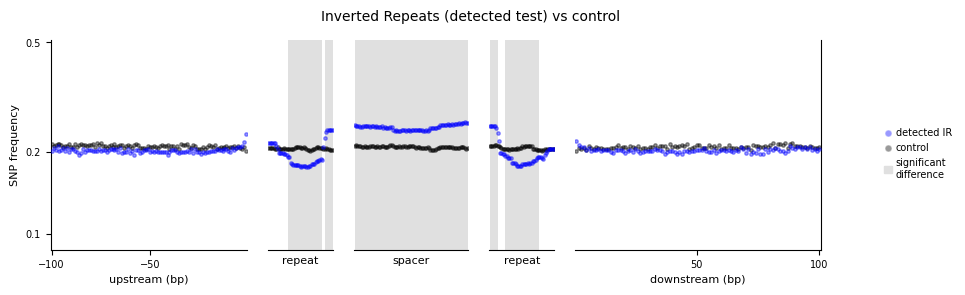

In [22]:
# 5-panel log-scale plot (matplotlib replacement of the R ggplot cell)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

COL_DR    = (0/255, 0/255, 255/255, 0.4)
COL_CTRL  = (0/255, 0/255, 0/255, 0.4)
COL_SIG   = (0.88, 0.88, 0.88)
PT_SIZE   = 6
MIN_SIG_RUN = 5

fig = plt.figure(figsize=(10, 3))
gs = gridspec.GridSpec(1, 5, width_ratios=[60, 20, 35, 20, 75], wspace=0.15,
                       left=0.08, right=0.85, top=0.88, bottom=0.18)

all_vals = np.concatenate([
    left_freq, ctrl_left_freq, right_freq, ctrl_right_freq,
    rep_freqs["LeftRepeat"],  ctrl_rep_freqs["LeftRepeat"],
    rep_freqs["RightRepeat"], ctrl_rep_freqs["RightRepeat"],
    spacer_freq, ctrl_spacer_freq,
])
valid = all_vals[(all_vals > 0) & np.isfinite(all_vals)]
y_lo = valid.min() * 0.5 if len(valid) else 0.001
y_hi = valid.max() * 2.0 if len(valid) else 1.0
Y_TICKS = [t for t in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0] if y_lo <= t <= y_hi]
Y_FMT   = ticker.FuncFormatter(lambda x, _: f"{x:g}")

def _filter_short_runs(mask, min_run=MIN_SIG_RUN):
    out = mask.copy()
    n = len(out); i = 0
    while i < n:
        if out[i]:
            j = i
            while j < n and out[j]: j += 1
            if j - i < min_run: out[i:j] = False
            i = j
        else:
            i += 1
    return out

def _add_sig_shading(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo, y_hi, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_flank(ax, x, fdr, fct, sig, xlabel, show_y=False, is_left=True):
    _add_sig_shading(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fdr, s=PT_SIZE, color=COL_DR,   zorder=3)
    ax.set_yscale("log"); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS))
        ax.yaxis.set_major_formatter(Y_FMT)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left:
        ax.spines["right"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

def plot_part(ax, x, fdr, fct, sig, xlabel, n_bins):
    _add_sig_shading(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fdr, s=PT_SIZE, color=COL_DR,   zorder=3)
    ax.set_yscale("log"); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.set_xlim(0.5, n_bins + 0.5); ax.set_xticks([])
    ax.yaxis.set_visible(False)
    for sp in ("left","right","top"): ax.spines[sp].set_visible(False)

ax0 = fig.add_subplot(gs[0])
plot_flank(ax0, left_x, left_freq, ctrl_left_freq, sig_left,
           "upstream (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig.add_subplot(gs[1])
plot_part(ax1, repeat_x, rep_freqs["LeftRepeat"], ctrl_rep_freqs["LeftRepeat"],
          sig_parts["LeftRepeat"], "repeat", REPEAT_BINS)

ax2 = fig.add_subplot(gs[2])
plot_part(ax2, spacer_x, spacer_freq, ctrl_spacer_freq,
          sig_parts["Spacer"], "spacer", SPACER_BINS)

ax3 = fig.add_subplot(gs[3])
plot_part(ax3, repeat_x, rep_freqs["RightRepeat"], ctrl_rep_freqs["RightRepeat"],
          sig_parts["RightRepeat"], "repeat", REPEAT_BINS)

ax4 = fig.add_subplot(gs[4])
plot_flank(ax4, right_x, right_freq, ctrl_right_freq, sig_right,
           "downstream (bp)", show_y=False, is_left=False)
ax4.set_xlim(0.5, MAX_FLANK + 0.5); ax4.set_xticks([50, 100])

fig.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_DR,   markersize=5, label="detected IR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\ndifference"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.99, 0.5),
)
fig.suptitle("Inverted Repeats (detected test) vs control", fontsize=10, y=0.98)

out_pdf = "ir_snp_frequency_notebook.pdf"
out_png = "ir_snp_frequency_notebook.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf} and {out_png}")
plt.show()


## 2.7b Plot Results (official R IWTomics + ggplot)

Re-run the IWTomics significance test (cell 25) using the **official IWTomics R Bioconductor package** (Pini & Vantini 2017, IWTomics 1.36) instead of the in-notebook Python permutation `iwtomics()`, then re-plot the 5-panel figure (LeftFlank | LeftRepeat | Spacer | RightRepeat | RightFlank) using `ggplot2`. The blue (motif) and black (control) per-bin frequencies stay the same; the gray shading is now the official R IWTomics adjusted p-value < 0.01 mask, computed once per sub-part (5 separate `IWTomicsTest` calls).



### Running the R script

A standalone R script is saved at `iwtomics_ir/run_iwtomics_ir.R`. It reads `NCNR.InvertedRepeats.gnomAD.intersect` and `NCNR.InvertedRepeats.gnomAD.shuffled.intersect` directly, builds per-locus matrices for the 5 sub-parts, and runs `IWTomicsTest(..., statistics="mean", B=1000)` once per sub-part. Outputs:

* `InvertedRepeats_motif_vs_control_IWTomics_left_0.01.RData` -> `adj_pvalue_curve_left`
* `InvertedRepeats_motif_vs_control_IWTomics_center_0.01.RData` -> `adj_pvalue_curve_center` (with `subpart` column for LeftRepeat/Spacer/RightRepeat)
* `InvertedRepeats_motif_vs_control_IWTomics_right_0.01.RData` -> `adj_pvalue_curve_right`

Run interactively:

```bash
$R_BIN
> source("/path/to/snp_af_analysis/iwtomics_ir/run_iwtomics_ir.R")
```

Or batch-run:

```bash
$R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_ir/run_iwtomics_ir.R
```

Note on Spacer: zero-spacer loci (motif_len = 2*repeat) produce all-zero rows in the Spacer matrix. The Python pipeline passes the full matrix to its `iwtomics()` (so zero-spacer loci enter as zero rows) but divides plotted freq by `N_MOTIF_SPACER`. The R port mirrors this exact behavior so the two pipelines are directly comparable.

Once the three `.RData` files are on disk, run the plot cell below.


N_MOTIF=22253(16526 spacer)  N_CTRL=23033(17169 spacer)
building matrices (motif) ...
building matrices (control) ...
wrote iwt_ir_freq_{LeftFlank,RightFlank,center}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved ir_snp_frequency_notebook_iwtomics.{pdf,png}



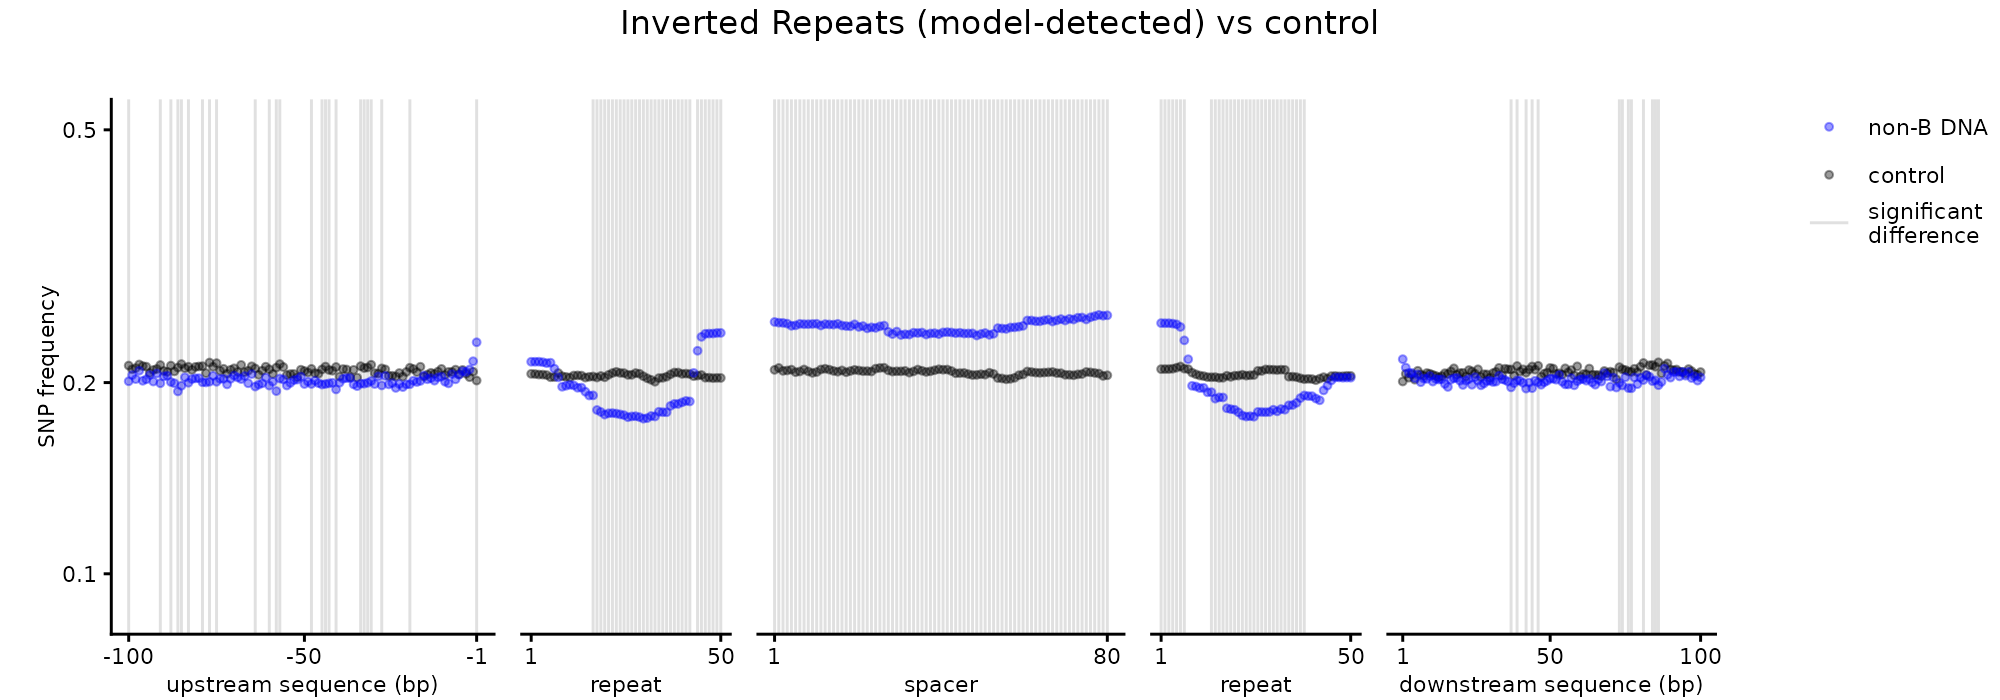

In [14]:
# R + ggplot 5-panel plot using official IWTomics .RData
# Re-builds per-locus matrices from .intersect files (mirror
# of cell 25 _build_matrices_iwt, no Python permutation), writes per-bin freq CSVs,
# then plots via R + ggplot.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/ir_notebook_detected_run"
os.chdir(WORKDIR)

# parameters (must match run_iwtomics_ir.R)
MAX_FLANK    = 100
REPEAT_BINS  = 50
SPACER_BINS  = 80
PART_LEN = {"LeftRepeat": REPEAT_BINS, "Spacer": SPACER_BINS, "RightRepeat": REPEAT_BINS}
scaledposRepeat = [round(i, 4) for i in np.arange(1, REPEAT_BINS * 2, 2.0) / (REPEAT_BINS * 2)]
scaledposSpacer = [round(i, 4) for i in np.arange(1, SPACER_BINS * 2, 2.0) / (SPACER_BINS * 2)]

# counts from split_counts.txt
_counts = {k: int(v) for k, v in
           (line.split("\t") for line in Path("split_counts.txt").read_text().strip().splitlines())}
N_MOTIF        = _counts["N_MOTIF"]
N_MOTIF_SPACER = _counts["N_MOTIF_SPACER"]
N_CTRL         = _counts["N_CTRL"]
N_CTRL_SPACER  = _counts["N_CTRL_SPACER"]
print(f"N_MOTIF={N_MOTIF}({N_MOTIF_SPACER} spacer)  N_CTRL={N_CTRL}({N_CTRL_SPACER} spacer)")

# build per-locus matrices (mirror of cell 25 _build_matrices_iwt)
def _build_matrices_iwt(intersect_path, n_loci):
    out = {
        "left":        np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "right":       np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "LeftRepeat":  np.zeros((n_loci, REPEAT_BINS), dtype=np.float32),
        "Spacer":      np.zeros((n_loci, SPACER_BINS), dtype=np.float32),
        "RightRepeat": np.zeros((n_loci, REPEAT_BINS), dtype=np.float32),
    }
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: out["left"][lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: out["right"][lid, idx] += 1
            elif ptype in PART_LEN and plen > 0:
                grid = scaledposRepeat if ptype.endswith("Repeat") else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(grid):
                    if sp >= fs and sp < fe:
                        out[ptype][lid, i] += 1
    return out

print("building matrices (motif) ...")
mot = _build_matrices_iwt("NCNR.InvertedRepeats.gnomAD.intersect",          N_MOTIF)
print("building matrices (control) ...")
ctl = _build_matrices_iwt("NCNR.InvertedRepeats.gnomAD.shuffled.intersect", N_CTRL)

# per-bin frequencies -> CSVs
# Spacer divisor is N_*_SPACER (matches Python pipeline cell 25)
def _freq(m, n): return m.sum(0) / n

pd.DataFrame({"LeftFlank":  _freq(mot["left"],  N_MOTIF),
              "ctrl_LeftFlank":  _freq(ctl["left"],  N_CTRL)}
             ).to_csv("iwt_ir_freq_LeftFlank.csv",  index=False)
pd.DataFrame({"RightFlank": _freq(mot["right"], N_MOTIF),
              "ctrl_RightFlank": _freq(ctl["right"], N_CTRL)}
             ).to_csv("iwt_ir_freq_RightFlank.csv", index=False)

center_df = {
    "LeftRepeat":       _freq(mot["LeftRepeat"],  N_MOTIF),
    "ctrl_LeftRepeat":  _freq(ctl["LeftRepeat"],  N_CTRL),
    "Spacer":           _freq(mot["Spacer"],      N_MOTIF_SPACER),
    "ctrl_Spacer":      _freq(ctl["Spacer"],      N_CTRL_SPACER),
    "RightRepeat":      _freq(mot["RightRepeat"], N_MOTIF),
    "ctrl_RightRepeat": _freq(ctl["RightRepeat"], N_CTRL),
}
maxL = max(PART_LEN.values())  # 80
center_padded = {k: np.concatenate([v, np.full(maxL - len(v), np.nan)]) for k, v in center_df.items()}
pd.DataFrame(center_padded).to_csv("iwt_ir_freq_center.csv", index=False)
print("wrote iwt_ir_freq_{LeftFlank,RightFlank,center}.csv")

# R + ggplot
R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r"""
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/ir_notebook_detected_run")

load("InvertedRepeats_motif_vs_control_IWTomics_left_0.01.RData")
load("InvertedRepeats_motif_vs_control_IWTomics_right_0.01.RData")
load("InvertedRepeats_motif_vs_control_IWTomics_center_0.01.RData")

freqL <- read.csv("iwt_ir_freq_LeftFlank.csv")
freqR <- read.csv("iwt_ir_freq_RightFlank.csv")
freqC <- read.csv("iwt_ir_freq_center.csv")

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                           Freq   = freqL$LeftFlank,
                           C_Freq = freqL$ctrl_LeftFlank,
                           Signif = adj_pvalue_curve_left$significant)
RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                           Freq   = freqR$RightFlank,
                           C_Freq = freqR$ctrl_RightFlank,
                           Signif = adj_pvalue_curve_right$significant)

mk_part <- function(name, n_bins) {
  sig_rows <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == name, ]
  data.frame(Levels = seq_len(n_bins),
             Freq   = freqC[[name]][1:n_bins],
             C_Freq = freqC[[paste0("ctrl_", name)]][1:n_bins],
             Signif = sig_rows$significant)
}
LRDf <- mk_part("LeftRepeat",  50)
SPDf <- mk_part("Spacer",      80)
RRDf <- mk_part("RightRepeat", 50)

allv <- c(LeftFlankDf$Freq,  LeftFlankDf$C_Freq,
          RightFlankDf$Freq, RightFlankDf$C_Freq,
          LRDf$Freq, LRDf$C_Freq,
          SPDf$Freq, SPDf$C_Freq,
          RRDf$Freq, RRDf$C_Freq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c("non-B DNA"               = rgb(t(col2rgb("blue")),  alpha = 100, maxColorValue = 255),
          "significant\ndifference" = "grey88",
          "control"                 = rgb(t(col2rgb("black")), alpha = 100, maxColorValue = 255))

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

base_panel <- function(df, xlab, n_bins) {
  ggplot(df, aes(x = Levels)) +
    geom_vline(xintercept = df$Levels[df$Signif], col = "gray88") +
    geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
    geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
    theme_classic() +
    theme(legend.position = "none",
          axis.text.x  = element_text(size = 8, family = "sans"),
          axis.title.x = element_text(size = 8, family = "sans"),
          axis.title.y = element_blank(),
          axis.text.y  = element_blank(),
          axis.ticks.y = element_blank(),
          axis.line.y  = element_blank()) +
    labs(x = xlab) +
    scale_colour_manual(name = "", values = cols) +
    scale_x_continuous(breaks = c(1, n_bins), limits = c(1, n_bins)) +
    theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
    scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)
}
p2 <- base_panel(LRDf, "repeat", 50)
p3 <- base_panel(SPDf, "spacer", 80)
p4 <- base_panel(RRDf, "repeat", 50)

p5 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\ndifference")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 8, family = "sans"),
        legend.position        = "inside",
        legend.position.inside = c(1.55, 0.90),
        legend.background     = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("non-B DNA", "control", "significant\ndifference")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 3))

g <- arrangeGrob(p1, p2, p3, p4, p5, ncol = 5,
                 widths = unit(c(60, 30, 50, 30, 75),
                               c("mm","mm","mm","mm","mm")),
                 top = textGrob("Inverted Repeats (model-detected) vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("ir_snp_frequency_notebook_iwtomics.pdf", g, width = 10, height = 3.5, dpi = 300, bg='white')
ggsave("ir_snp_frequency_notebook_iwtomics.png", g, width = 10, height = 3.5, dpi = 200, bg='white')
cat("saved ir_snp_frequency_notebook_iwtomics.{pdf,png}\n")
"""

Path("plot_ir_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_ir_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("ir_snp_frequency_notebook_iwtomics.png"))


## 2.8 Permuting tests and controls

Generates the permuted-null CSVs (1000 permutations) that feed IWTomics.
Args for `Permuting.py` are:
`<motif_csv> <ctrl_csv> N_motif N_motif_spacer N_ctrl N_ctrl_spacer <out_motif> <out_ctrl>`

Fill in the four counts from the `Split.py` printout for this run:
`LociCount` and `LociCount − ZeroSpacers` for the motif and the control.


In [ ]:
#Permuting.py

import sys
import random
from collections import Counter
import pandas as pd

def extract_pos(infile): # this extract all snps in different \
                        #sections of a same non-B DNA loci
    infile.readline() #skip first line
    loci = {}
    last_pos = ''
    for line in infile:
        array = line.strip().split(',')
      
        if len(array) == 12: # G4s have one more columns, snp_pos is the section, snp_distance is the scaled position
            chrom, start, end, snp_pos, snpdistance = array[1], array[2], array[3], array[8], array[9]
        elif len(array) == 11:
            chrom, start, end, snp_pos, snpdistance = array[1], array[2], array[3], array[7], array[8]            
        else:
            print('Array length error')
        
        #next we group all SNPs that came from the same non-B locus
        if snp_pos == 'flank1' or snp_pos == 'LeftFlank':
            if last_pos == 'flank2' or last_pos == 'RightFlank':#should always be the start of a locus but the first one
                locus = chrom+"|"+start+"|"+end
                loci[locus] = locus_array
                
                locus_start = start
                locus_array = []
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)
                
            elif last_pos == '':#first start
                locus_start = start
                locus_array = []
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)  
                
            else:
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)
        else:
            if snpdistance!= 'NA':
                locus_array.append(snp_pos+'|'+snpdistance)
            locus_end = end
            
        last_pos = snp_pos
            
    locus = chrom+"|"+start+"|"+end #last iteration
    loci[locus] = locus_array #last iteration
    return(loci)

def count_freqs(loci, denominator, optional_denominator):
    
    subparts = {}
    for locus in loci:

        
        for snp in locus:        
            snp_pos, snp_coord = snp.split('|')
            if snp_pos in subparts:
                subparts[snp_pos].append(snp_coord)
            else:
                subparts[snp_pos] = [snp_coord]
            
    rows = []
    for subpart in subparts:
        freq = Counter(subparts[subpart])
        for value in freq.items():
            snp_coord, count = value
            if subpart == 'Spacer':
                freq = float(count) / optional_denominator
            else:
                freq = float(count) / denominator
            
            rows.append([subpart, float(snp_coord), freq])
        
    return(rows)
    

colnames = ['subpart','snp_coord','freq']

pool = []

infile = open(sys.argv[1], 'rt')
loci_dict = extract_pos(infile)
loci = []


for locus in loci_dict:
    pool.append(loci_dict[locus])
    loci.append(loci_dict[locus])
    
first_col = count_freqs(loci, int(sys.argv[3]), int(sys.argv[4]))
loci_df = pd.DataFrame(data=first_col, columns=colnames)


infile = open(sys.argv[2], 'rt')
ctrl_loci_dict = extract_pos(infile)
ctrl_loci = []

for locus in ctrl_loci_dict:
    pool.append(ctrl_loci_dict[locus])
    ctrl_loci.append(ctrl_loci_dict[locus])

first_ctrl_col = count_freqs(ctrl_loci, int(sys.argv[5]), int(sys.argv[6]))    
ctrl_loci_df = pd.DataFrame(data=first_ctrl_col, columns=colnames)



permutation = 1
while permutation <= 1000:
    colnames = ['subpart','snp_coord', 'freq '+str(permutation)]

    random.shuffle(pool)
    random_loci = pool[:int(sys.argv[3])]
    random_ctrl_loci = pool[int(sys.argv[3]):]
    
    
    new_col = count_freqs(random_loci, int(sys.argv[3]), int(sys.argv[4]))
    new_ctrl_col = count_freqs(random_ctrl_loci, int(sys.argv[5]), int(sys.argv[6]))
    new_df = pd.DataFrame(data=new_col, columns=colnames)
    new_ctrl_df = pd.DataFrame(data=new_ctrl_col, columns=colnames)

    loci_df = pd.merge(loci_df, new_df, how='outer', on=['subpart','snp_coord'])
    ctrl_loci_df = pd.merge(ctrl_loci_df, new_ctrl_df, how='outer', on=['subpart','snp_coord'])

    permutation += 1



pd.DataFrame.to_csv(loci_df, sys.argv[7])  
pd.DataFrame.to_csv(ctrl_loci_df, sys.argv[8])  


```
# Fill in the four counts from Split.py for this run, then run:
python Permuting.py \
    NCNR.InvertedRepeats.gnomAD.intersect.csv \
    NCNR.InvertedRepeats.gnomAD.shuffled.intersect.csv \
    <N_motif> <N_motif_nonzero_spacer> <N_ctrl> <N_ctrl_nonzero_spacer> \
    NCNR.InvertedRepeats.gnomAD.permuted \
    NCNR.InvertedRepeats.gnomAD.shuffled.permuted
```


## 2.9 Frequencies of subsitution types

In [ ]:
%%bash
# List SNPs at positions of interest and adjust coordinates for trinucleotide context
awk '{if ($5=="+") print $0 }' NCNR.InvertedRepeats.nooverlap.bed | awk 'BEGIN {OFS="\t"} {print $1, $6-2, $6+1}' | awk '{if ($2>0) print $0}'> NCNR.InvertedRepeats.trinucl.left.bed
awk '{if ($5=="+") print $0 }' NCNR.InvertedRepeats.shuffled.nooverlap.bed | awk 'BEGIN {OFS="\t"} {print $1, $6-2, $6+1}' | awk '{if ($2>0) print $0}'> NCNR.InvertedRepeats.shuffled.trinucl.left.bed

awk '{if ($5=="+") print $0 }' NCNR.InvertedRepeats.nooverlap.bed |awk 'BEGIN {OFS="\t"} {print $1, $7-1, $7+2}' > NCNR.InvertedRepeats.trinucl.right.bed
awk '{if ($5=="+") print $0 }' NCNR.InvertedRepeats.shuffled.nooverlap.bed |awk 'BEGIN {OFS="\t"} {print $1, $7-1, $7+2}' > NCNR.InvertedRepeats.shuffled.trinucl.right.bed


```
bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.InvertedRepeats.trinucl.left.bed > NCNR.InvertedRepeats.trinucl.left.fa
bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.InvertedRepeats.shuffled.trinucl.left.bed > NCNR.InvertedRepeats.shuffled.trinucl.left.fa

bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.InvertedRepeats.trinucl.right.bed > NCNR.InvertedRepeats.trinucl.right.fa
bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.InvertedRepeats.shuffled.trinucl.right.bed > NCNR.InvertedRepeats.shuffled.trinucl.right.fa
```

In [ ]:
## Match SNPs of interest with SNP dictionary to obtain substitution type
import itertools

Test = open('NCNR.InvertedRepeats.trinucl.left.fa', 'rt')
Control = open('NCNR.InvertedRepeats.shuffled.trinucl.left.fa', 'rt')

permutations = itertools.permutations(['A','T','G','C'], 2)
rows = []
for permutation in permutations:
    rows.append(trinucl_test(snpdict, Test, Control, permutation[0], permutation[1]))
    Test.seek(0)
    Control.seek(0)
    
colnames = ['ref','alt','test freq','ctrl freq', 'odds ratio', 'pvalue']
trinucl_df = pd.DataFrame(data=rows, columns=colnames)

trinucl_df = trinucl_df[trinucl_df['test freq'] != 'NA']

p_adjusted = multipletests(trinucl_df.pvalue, alpha=0.05, method='bonferroni')

trinucl_df['Adj. p-val'] = p_adjusted[1] 
del trinucl_df['pvalue']
print(trinucl_df)


In [ ]:
## Match SNPs of interest with SNP dictionary to obtain substitution type
import itertools

Test = open('NCNR.InvertedRepeats.trinucl.right.fa', 'rt')
Control = open('NCNR.InvertedRepeats.shuffled.trinucl.right.fa', 'rt')

permutations = itertools.permutations(['A','T','G','C'], 2)
rows = []
for permutation in permutations:
    rows.append(trinucl_test(snpdict, Test, Control, permutation[0], permutation[1]))
    Test.seek(0)
    Control.seek(0)
    
colnames = ['ref','alt','test freq','ctrl freq', 'odds ratio', 'pvalue']
trinucl_df = pd.DataFrame(data=rows, columns=colnames)

trinucl_df = trinucl_df[trinucl_df['test freq'] != 'NA']

p_adjusted = multipletests(trinucl_df.pvalue, alpha=0.05, method='bonferroni')

trinucl_df['Adj. p-val'] = p_adjusted[1] 
del trinucl_df['pvalue']
print(trinucl_df)


## 2.10 Add undetected IR signal

Build the **undetected** IR pool = all `label == 'Inverted_Repeat'` rows from the test CSV minus the gofae-detected rows. Run the same pipeline (NCNR filter → 100-bp threshold → flanks → locuschoice → split → gnomAD intersect → per-locus matrix). The detected/control matrices already in memory are reused as-is.

The new plot overlays three series — **detected (blue)**, **undetected (orange)**, **control (black)** — and the significance shading is the IWTomics test of **detected vs undetected** (not detected vs control).


In [16]:
# 2.10.1 Build the undetected IR pool = all-test IR minus detected
TEST_CSV = f"{EXPERIMENT_DATA}/Inverted_Repeat_test.csv"
IR_BED   = f"{PU_RESULTS}/Inverted_Repeat/Inverted_Repeat_detected.bed"

# All-test IR (label == 'Inverted_Repeat'), still 1-based for matching
df_all = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","features","label"])
df_all = df_all[df_all["label"] == "Inverted_Repeat"].copy()
df_all = df_all.dropna(subset=["motif_start","motif_end","features"]).reset_index(drop=True)
df_all["motif_start"] = df_all["motif_start"].astype(int)
df_all["motif_end"]   = df_all["motif_end"].astype(int)
df_all = df_all.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)

# Pull spacer from features field
_re_spacer = re.compile(r"spacer=(\d+)")
df_all["spacer"] = df_all["features"].apply(
    lambda s: int(_re_spacer.search(str(s)).group(1)) if _re_spacer.search(str(s)) else None)
df_all = df_all.dropna(subset=["spacer"]).reset_index(drop=True)
df_all["spacer"] = df_all["spacer"].astype(int)

# Detected coords (1-based) for the set difference
df_det_min = pd.read_csv(IR_BED, sep="\t", usecols=["chr","strand","motif_start","motif_end"])
df_det_min["motif_start"] = df_det_min["motif_start"].astype(int)
df_det_min["motif_end"]   = df_det_min["motif_end"].astype(int)
df_det_min = df_det_min.drop_duplicates().assign(_is_det=True)

df_undet = df_all.merge(df_det_min, on=["chr","motif_start","motif_end","strand"], how="left")
df_undet = df_undet[df_undet["_is_det"].isna()].drop(columns=["_is_det"]).reset_index(drop=True)
print(f"all-test IR: {len(df_all)}, detected: {len(df_det_min)}, undetected: {len(df_undet)}")

# 1-based inclusive → 0-based half-open (mirror of cell 9: only motif_start needs −1)
df_undet["motif_start"] = df_undet["motif_start"] - 1

df_undet[["chr","motif_start","motif_end","spacer"]].to_csv(
    "InvertedRepeats.undet.bed", sep="\t", header=False, index=False)
print(f"wrote InvertedRepeats.undet.bed with {len(df_undet)} rows")


all-test IR: 1884420, detected: 46530, undetected: 1837890
wrote InvertedRepeats.undet.bed with 1837890 rows


In [17]:
%%bash
set -euo pipefail

# NCNR filter (undetected) — relies on NCNR.hg38.bed already built in cell 11
bedtools intersect -a InvertedRepeats.undet.bed -b NCNR.hg38.bed -v > NCNR.InvertedRepeats.undet.bed
awk '{if ($3-$2<=100) print $0}' NCNR.InvertedRepeats.undet.bed \
    > NCNR.InvertedRepeats.undet.100threshold.bed
bedtools sort -i NCNR.InvertedRepeats.undet.100threshold.bed \
    > NCNR.InvertedRepeats.undet.100threshold.sorted.bed

paste NCNR.InvertedRepeats.undet.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.InvertedRepeats.undet.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNR.InvertedRepeats.undet.flanked.bed

wc -l InvertedRepeats.undet.bed \
      NCNR.InvertedRepeats.undet.bed \
      NCNR.InvertedRepeats.undet.100threshold.sorted.bed \
      NCNR.InvertedRepeats.undet.flanked.bed
head -2 NCNR.InvertedRepeats.undet.flanked.bed


  1837890 InvertedRepeats.undet.bed
   905786 NCNR.InvertedRepeats.undet.bed
   887035 NCNR.InvertedRepeats.undet.100threshold.sorted.bed
   887035 NCNR.InvertedRepeats.undet.flanked.bed
  4517746 total
chr1	16060	20074	14	+	18060	18074	2
chr1	16750	20762	12	+	18750	18762	0


In [18]:
# 2.10.2 locuschoice + split + per-chrom gnomAD intersect (undetected)
locuschoice("NCNR.InvertedRepeats.undet.flanked.bed",
            "NCNR.InvertedRepeats.undet.nooverlap.bed", seed=44)

n_undet, zs_undet = split_repeats("NCNR.InvertedRepeats.undet.nooverlap.bed",
                                  "NCNR.InvertedRepeats.undet.split.bed")
N_UNDET        = n_undet
N_UNDET_SPACER = n_undet - zs_undet
print(f"\nN_UNDET={N_UNDET}  N_UNDET_SPACER={N_UNDET_SPACER}")

subprocess.run(
    "bedtools sort -i NCNR.InvertedRepeats.undet.split.bed > _s.bed "
    "&& mv _s.bed NCNR.InvertedRepeats.undet.split.bed",
    shell=True, check=True,
)
intersect_per_chrom("NCNR.InvertedRepeats.undet.split.bed",
                    "NCNR.InvertedRepeats.gnomAD.undet.intersect")


NCNR.InvertedRepeats.undet.flanked.bed -> NCNR.InvertedRepeats.undet.nooverlap.bed: kept 202642
NCNR.InvertedRepeats.undet.nooverlap.bed -> NCNR.InvertedRepeats.undet.split.bed: 202375 Loci, 34308 ZeroSpacers, skipped=267

N_UNDET=202375  N_UNDET_SPACER=168067
  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNR.InvertedRepeats.undet.split.bed -> NCNR.InvertedRepeats.gnomAD.undet.intersect: 208601529 lines


208601529

In [19]:
# 2.10.3 Build matrices for undetected, then run IWTomics (detected vs undetected)
print("Building per-locus matrices (undetected) …")
u_left, u_center, u_right = _build_matrices("NCNR.InvertedRepeats.gnomAD.undet.intersect", N_UNDET)

print("IWTomics – left flank (detected vs undetected) …")
sig_dvu_left   = iwtomics(dr_left,   u_left)
print(f"  significant positions: {sig_dvu_left.sum()}/{MAX_FLANK}")
print("IWTomics – center (detected vs undetected) …")
sig_dvu_center = iwtomics(dr_center, u_center)
print(f"  significant bins: {sig_dvu_center.sum()}/{CENTER_BINS}")
print("IWTomics – right flank (detected vs undetected) …")
sig_dvu_right  = iwtomics(dr_right,  u_right)
print(f"  significant positions: {sig_dvu_right.sum()}/{MAX_FLANK}")

sig_dvu_parts = {
    name: sig_dvu_center[off : off + (REPEAT_BINS if name.endswith("Repeat") else SPACER_BINS)]
    for name, off in part_offsets.items()
}

undet_left_freq  = u_left.sum(0)  / N_UNDET
undet_right_freq = u_right.sum(0) / N_UNDET
undet_rep_freqs = {
    "LeftRepeat":  u_center[:, 0            : REPEAT_BINS                ].sum(0) / N_UNDET,
    "RightRepeat": u_center[:, REPEAT_BINS + SPACER_BINS : CENTER_BINS   ].sum(0) / N_UNDET,
}
undet_spacer_freq = u_center[:, REPEAT_BINS : REPEAT_BINS + SPACER_BINS].sum(0) / max(N_UNDET_SPACER, 1)

print(f"\nundet flank min/max:  {undet_left_freq.min():.4f} .. {undet_right_freq.max():.4f}")
print(f"undet spacer min/max: {undet_spacer_freq.min():.4f} .. {undet_spacer_freq.max():.4f}")


Building per-locus matrices (undetected) …
IWTomics – left flank (detected vs undetected) …
  significant positions: 2/100
IWTomics – center (detected vs undetected) …
  significant bins: 43/180
IWTomics – right flank (detected vs undetected) …
  significant positions: 0/100

undet flank min/max:  0.1966 .. 0.2060
undet spacer min/max: 0.2121 .. 0.2174


saved ir_snp_frequency_notebook_detected_with_undet.pdf and ir_snp_frequency_notebook_detected_with_undet.png


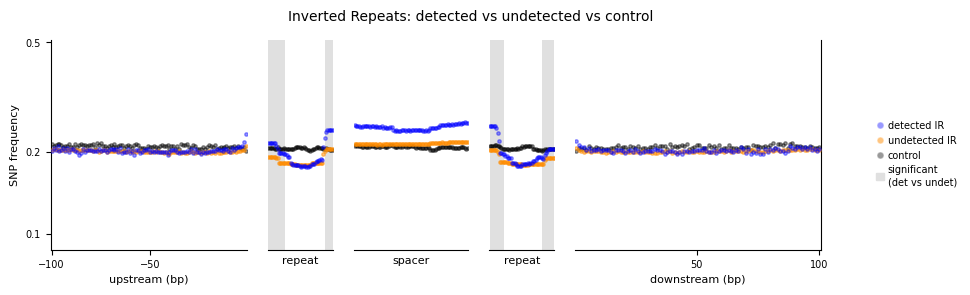

In [23]:
# 2.10.4 Plot — detected (blue) + undetected (orange) + control (black)
# Significance shading = IWTomics(detected vs undetected)
COL_UND = (255/255, 140/255, 0/255, 0.5)   # orange

fig = plt.figure(figsize=(10, 3))
gs = gridspec.GridSpec(1, 5, width_ratios=[60, 20, 35, 20, 75], wspace=0.15,
                       left=0.08, right=0.85, top=0.88, bottom=0.18)

all_vals2 = np.concatenate([
    left_freq, ctrl_left_freq, right_freq, ctrl_right_freq,
    undet_left_freq, undet_right_freq,
    rep_freqs["LeftRepeat"],  ctrl_rep_freqs["LeftRepeat"],  undet_rep_freqs["LeftRepeat"],
    rep_freqs["RightRepeat"], ctrl_rep_freqs["RightRepeat"], undet_rep_freqs["RightRepeat"],
    spacer_freq, ctrl_spacer_freq, undet_spacer_freq,
])
valid2 = all_vals2[(all_vals2 > 0) & np.isfinite(all_vals2)]
y_lo2 = valid2.min() * 0.5 if len(valid2) else 0.001
y_hi2 = valid2.max() * 2.0 if len(valid2) else 1.0
Y_TICKS2 = [t for t in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0] if y_lo2 <= t <= y_hi2]

def _add_sig_shading2(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo2, y_hi2, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_flank3(ax, x, fdr, fct, fu, sig, xlabel, show_y, is_left):
    _add_sig_shading2(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fu,  s=PT_SIZE, color=COL_UND,  zorder=3)
    ax.scatter(x, fdr, s=PT_SIZE, color=COL_DR,   zorder=4)
    ax.set_yscale("log"); ax.set_ylim(y_lo2, y_hi2)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS2))
        ax.yaxis.set_major_formatter(Y_FMT)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left: ax.spines["right"].set_visible(False)
    else:       ax.spines["left"].set_visible(False)

def plot_part3(ax, x, fdr, fct, fu, sig, xlabel, n_bins):
    _add_sig_shading2(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fu,  s=PT_SIZE, color=COL_UND,  zorder=3)
    ax.scatter(x, fdr, s=PT_SIZE, color=COL_DR,   zorder=4)
    ax.set_yscale("log"); ax.set_ylim(y_lo2, y_hi2)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.set_xlim(0.5, n_bins + 0.5); ax.set_xticks([])
    ax.yaxis.set_visible(False)
    for sp in ("left","right","top"): ax.spines[sp].set_visible(False)

ax0 = fig.add_subplot(gs[0])
plot_flank3(ax0, left_x, left_freq, ctrl_left_freq, undet_left_freq, sig_dvu_left,
            "upstream (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig.add_subplot(gs[1])
plot_part3(ax1, repeat_x, rep_freqs["LeftRepeat"], ctrl_rep_freqs["LeftRepeat"], undet_rep_freqs["LeftRepeat"],
           sig_dvu_parts["LeftRepeat"], "repeat", REPEAT_BINS)

ax2 = fig.add_subplot(gs[2])
plot_part3(ax2, spacer_x, spacer_freq, ctrl_spacer_freq, undet_spacer_freq,
           sig_dvu_parts["Spacer"], "spacer", SPACER_BINS)

ax3 = fig.add_subplot(gs[3])
plot_part3(ax3, repeat_x, rep_freqs["RightRepeat"], ctrl_rep_freqs["RightRepeat"], undet_rep_freqs["RightRepeat"],
           sig_dvu_parts["RightRepeat"], "repeat", REPEAT_BINS)

ax4 = fig.add_subplot(gs[4])
plot_flank3(ax4, right_x, right_freq, ctrl_right_freq, undet_right_freq, sig_dvu_right,
            "downstream (bp)", show_y=False, is_left=False)
ax4.set_xlim(0.5, MAX_FLANK + 0.5); ax4.set_xticks([50, 100])

fig.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_DR,   markersize=5, label="detected IR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_UND,  markersize=5, label="undetected IR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\n(det vs undet)"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.995, 0.5),
)
fig.suptitle("Inverted Repeats: detected vs undetected vs control", fontsize=10, y=0.98)

out_pdf2 = "ir_snp_frequency_notebook_detected_with_undet.pdf"
out_png2 = "ir_snp_frequency_notebook_detected_with_undet.png"
fig.savefig(out_pdf2, dpi=300, bbox_inches="tight")
fig.savefig(out_png2, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf2} and {out_png2}")
plt.show()


## 2.10b Plot detected / undetected / control (official R IWTomics + ggplot)

Re-run the IWTomics significance for **detected vs undetected** (cell 39) using the **official IWTomics R Bioconductor package** (Pini & Vantini 2017, IWTomics 1.36) instead of the Python permutation, then re-plot the 5-panel figure (detected / undetected / control) using `ggplot2`. Blue (detected) and black (control) per-bin frequencies are unchanged from section 2.7b; orange (undetected) is added; gray shading is now the official R IWTomics adjusted p-value < 0.01 mask, computed once per sub-part.



### Running the R script

A standalone R script is saved at `iwtomics_ir/run_iwtomics_ir_dvu.R`. It reads `NCNR.InvertedRepeats.gnomAD.intersect` (detected) and `NCNR.InvertedRepeats.gnomAD.undet.intersect` (undetected) directly, builds per-locus matrices for the 5 sub-parts, and runs `IWTomicsTest(..., statistics="mean", B=1000)` once per sub-part. Outputs:

* `InvertedRepeats_detected_vs_undetected_IWTomics_left_0.01.RData` -> `adj_pvalue_curve_left`
* `InvertedRepeats_detected_vs_undetected_IWTomics_center_0.01.RData` -> `adj_pvalue_curve_center` (with `subpart` column for LeftRepeat/Spacer/RightRepeat)
* `InvertedRepeats_detected_vs_undetected_IWTomics_right_0.01.RData` -> `adj_pvalue_curve_right`

Run interactively:

```bash
$R_BIN
> source("/path/to/snp_af_analysis/iwtomics_ir/run_iwtomics_ir_dvu.R")
```

Or batch-run:

```bash
$R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_ir/run_iwtomics_ir_dvu.R
```

`run_iwtomics_ir_dvu.R` will append `N_UNDET` and `N_UNDET_SPACER` to `split_counts.txt` on the first run so the plotting cell below can pick them up. Once the three `.RData` files are on disk, run the plot cell below.


N_DET=22253(16526 spacer)  N_UNDET=202372(168066 spacer)  N_CTRL=23033(17169 spacer)
building matrices (detected) ...
building matrices (control) ...
building matrices (undetected) ...
wrote iwt_ir_freq_dvu_{LeftFlank,RightFlank,center}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved ir_snp_frequency_notebook_dvu_iwtomics.{pdf,png}



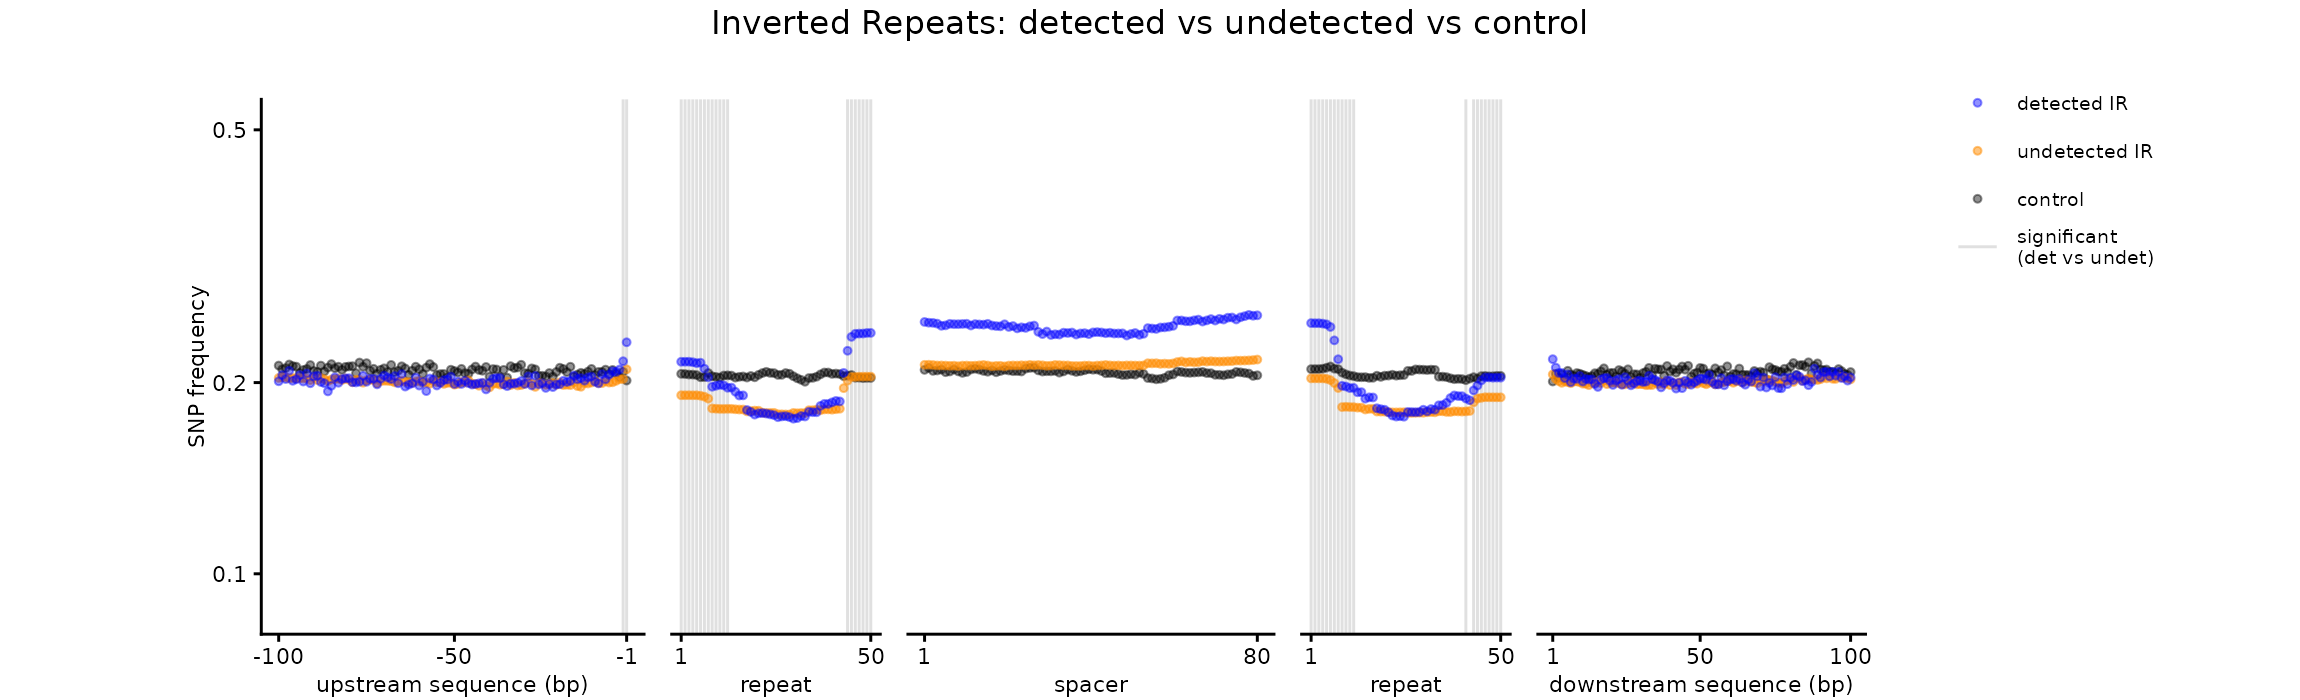

In [26]:
# R + ggplot 5-panel plot, detected / undetected / control
# Re-builds detected / control / undetected matrices and per-bin
# freqs, then plots via R + ggplot.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/ir_notebook_detected_run"
os.chdir(WORKDIR)

MAX_FLANK    = 100
REPEAT_BINS  = 50
SPACER_BINS  = 80
PART_LEN = {"LeftRepeat": REPEAT_BINS, "Spacer": SPACER_BINS, "RightRepeat": REPEAT_BINS}
scaledposRepeat = [round(i, 4) for i in np.arange(1, REPEAT_BINS * 2, 2.0) / (REPEAT_BINS * 2)]
scaledposSpacer = [round(i, 4) for i in np.arange(1, SPACER_BINS * 2, 2.0) / (SPACER_BINS * 2)]

_counts = {k: int(v) for k, v in
           (line.split("\t") for line in Path("split_counts.txt").read_text().strip().splitlines())}
N_DET, N_DET_SPACER = _counts["N_MOTIF"], _counts["N_MOTIF_SPACER"]
N_CTRL, N_CTRL_SPACER = _counts["N_CTRL"], _counts["N_CTRL_SPACER"]
if "N_UNDET" not in _counts or "N_UNDET_SPACER" not in _counts:
    raise RuntimeError(
        "N_UNDET / N_UNDET_SPACER not found in split_counts.txt -- run "
        "iwtomics_ir/run_iwtomics_ir_dvu.R first; it appends them.")
N_UNDET, N_UNDET_SPACER = _counts["N_UNDET"], _counts["N_UNDET_SPACER"]
print(f"N_DET={N_DET}({N_DET_SPACER} spacer)  "
      f"N_UNDET={N_UNDET}({N_UNDET_SPACER} spacer)  "
      f"N_CTRL={N_CTRL}({N_CTRL_SPACER} spacer)")

def _build_matrices_iwt(intersect_path, n_loci):
    out = {
        "left":        np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "right":       np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "LeftRepeat":  np.zeros((n_loci, REPEAT_BINS), dtype=np.float32),
        "Spacer":      np.zeros((n_loci, SPACER_BINS), dtype=np.float32),
        "RightRepeat": np.zeros((n_loci, REPEAT_BINS), dtype=np.float32),
    }
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: out["left"][lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: out["right"][lid, idx] += 1
            elif ptype in PART_LEN and plen > 0:
                grid = scaledposRepeat if ptype.endswith("Repeat") else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(grid):
                    if sp >= fs and sp < fe:
                        out[ptype][lid, i] += 1
    return out

print("building matrices (detected) ...")
det = _build_matrices_iwt("NCNR.InvertedRepeats.gnomAD.intersect",       N_DET)
print("building matrices (control) ...")
ctl = _build_matrices_iwt("NCNR.InvertedRepeats.gnomAD.shuffled.intersect", N_CTRL)
print("building matrices (undetected) ...")
und = _build_matrices_iwt("NCNR.InvertedRepeats.gnomAD.undet.intersect",  N_UNDET)

def _freq(m, n): return m.sum(0) / n

pd.DataFrame({
    "LeftFlank":       _freq(det["left"],  N_DET),
    "ctrl_LeftFlank":  _freq(ctl["left"],  N_CTRL),
    "undet_LeftFlank": _freq(und["left"],  N_UNDET),
}).to_csv("iwt_ir_freq_dvu_LeftFlank.csv",  index=False)

pd.DataFrame({
    "RightFlank":       _freq(det["right"], N_DET),
    "ctrl_RightFlank":  _freq(ctl["right"], N_CTRL),
    "undet_RightFlank": _freq(und["right"], N_UNDET),
}).to_csv("iwt_ir_freq_dvu_RightFlank.csv", index=False)

# Spacer divisor: per-data-source N_*_SPACER (matches Python pipeline)
center_df = {
    "LeftRepeat":        _freq(det["LeftRepeat"],  N_DET),
    "ctrl_LeftRepeat":   _freq(ctl["LeftRepeat"],  N_CTRL),
    "undet_LeftRepeat":  _freq(und["LeftRepeat"],  N_UNDET),
    "Spacer":            _freq(det["Spacer"],      N_DET_SPACER),
    "ctrl_Spacer":       _freq(ctl["Spacer"],      N_CTRL_SPACER),
    "undet_Spacer":      _freq(und["Spacer"],      N_UNDET_SPACER),
    "RightRepeat":       _freq(det["RightRepeat"], N_DET),
    "ctrl_RightRepeat":  _freq(ctl["RightRepeat"], N_CTRL),
    "undet_RightRepeat": _freq(und["RightRepeat"], N_UNDET),
}
maxL = max(PART_LEN.values())
center_padded = {k: np.concatenate([v, np.full(maxL - len(v), np.nan)]) for k, v in center_df.items()}
pd.DataFrame(center_padded).to_csv("iwt_ir_freq_dvu_center.csv", index=False)
print("wrote iwt_ir_freq_dvu_{LeftFlank,RightFlank,center}.csv")

R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r"""
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/ir_notebook_detected_run")

load("InvertedRepeats_detected_vs_undetected_IWTomics_left_0.01.RData")
load("InvertedRepeats_detected_vs_undetected_IWTomics_right_0.01.RData")
load("InvertedRepeats_detected_vs_undetected_IWTomics_center_0.01.RData")

freqL <- read.csv("iwt_ir_freq_dvu_LeftFlank.csv")
freqR <- read.csv("iwt_ir_freq_dvu_RightFlank.csv")
freqC <- read.csv("iwt_ir_freq_dvu_center.csv")

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                           Det    = freqL$LeftFlank,
                           Und    = freqL$undet_LeftFlank,
                           Ctrl   = freqL$ctrl_LeftFlank,
                           Signif = adj_pvalue_curve_left$significant)
RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                           Det    = freqR$RightFlank,
                           Und    = freqR$undet_RightFlank,
                           Ctrl   = freqR$ctrl_RightFlank,
                           Signif = adj_pvalue_curve_right$significant)

mk_part <- function(name, n_bins) {
  sig_rows <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == name, ]
  data.frame(Levels = seq_len(n_bins),
             Det    = freqC[[name]][1:n_bins],
             Und    = freqC[[paste0("undet_", name)]][1:n_bins],
             Ctrl   = freqC[[paste0("ctrl_",  name)]][1:n_bins],
             Signif = sig_rows$significant)
}
LRDf <- mk_part("LeftRepeat",  50)
SPDf <- mk_part("Spacer",      80)
RRDf <- mk_part("RightRepeat", 50)

allv <- c(LeftFlankDf$Det, LeftFlankDf$Und, LeftFlankDf$Ctrl,
          RightFlankDf$Det, RightFlankDf$Und, RightFlankDf$Ctrl,
          LRDf$Det, LRDf$Und, LRDf$Ctrl,
          SPDf$Det, SPDf$Und, SPDf$Ctrl,
          RRDf$Det, RRDf$Und, RRDf$Ctrl)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c(
  "detected IR"             = rgb(t(col2rgb("blue")),       alpha = 110, maxColorValue = 255),
  "undetected IR"           = rgb(t(col2rgb("darkorange")), alpha = 130, maxColorValue = 255),
  "control"                 = rgb(t(col2rgb("black")),      alpha = 110, maxColorValue = 255),
  "significant\n(det vs undet)" = "grey88"
)

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),       size = 1) +
  geom_point(aes(y = Und,  col = "undetected IR"), size = 1) +
  geom_point(aes(y = Det,  col = "detected IR"),   size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

base_panel <- function(df, xlab, n_bins) {
  ggplot(df, aes(x = Levels)) +
    geom_vline(xintercept = df$Levels[df$Signif], col = "gray88") +
    geom_point(aes(y = Ctrl, col = "control"),       size = 1) +
    geom_point(aes(y = Und,  col = "undetected IR"), size = 1) +
    geom_point(aes(y = Det,  col = "detected IR"),   size = 1) +
    theme_classic() +
    theme(legend.position = "none",
          axis.text.x  = element_text(size = 8, family = "sans"),
          axis.title.x = element_text(size = 8, family = "sans"),
          axis.title.y = element_blank(),
          axis.text.y  = element_blank(),
          axis.ticks.y = element_blank(),
          axis.line.y  = element_blank()) +
    labs(x = xlab) +
    scale_colour_manual(name = "", values = cols) +
    scale_x_continuous(breaks = c(1, n_bins), limits = c(1, n_bins)) +
    theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
    scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)
}
p2 <- base_panel(LRDf, "repeat", 50)
p3 <- base_panel(SPDf, "spacer", 80)
p4 <- base_panel(RRDf, "repeat", 50)

p5 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\n(det vs undet)")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),       size = 1) +
  geom_point(aes(y = Und,  col = "undetected IR"), size = 1) +
  geom_point(aes(y = Det,  col = "detected IR"),   size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 7, family = "sans"),
        legend.position        = "inside",
        legend.position.inside = c(1.55, 0.90),
        legend.background     = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("detected IR", "undetected IR", "control",
                                 "significant\n(det vs undet)")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 4))

g <- arrangeGrob(p1, p2, p3, p4, p5, ncol = 5,
                 widths = unit(c(60, 30, 50, 30, 75),
                               c("mm","mm","mm","mm","mm")),
                 top = textGrob("Inverted Repeats: detected vs undetected vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("ir_snp_frequency_notebook_dvu_iwtomics.pdf", g, width = 11.5, height = 3.5, dpi = 300,bg='white')
ggsave("ir_snp_frequency_notebook_dvu_iwtomics.png", g, width = 11.5, height = 3.5, dpi = 200,bg='white')
cat("saved ir_snp_frequency_notebook_dvu_iwtomics.{pdf,png}\n")
"""

Path("plot_ir_dvu_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_ir_dvu_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("ir_snp_frequency_notebook_dvu_iwtomics.png"))
